In [ ]:
import os

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="2"

In [2]:
from setproctitle import setproctitle
setproctitle("TRAINING_BEST_RESPONSE_DDQN")

In [3]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu, True)

2025-04-25 19:58:31.116360: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-25 19:58:31.116396: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-25 19:58:31.117769: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-25 19:58:31.124230: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-25 19:58:31.684427: W tensorflow/compiler/tf2

In [4]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
from tqdm import trange
from UltimateTicTacToeEnvSelfPlay import UltimateTicTacToeEnvSelfPlay
from DQNAgentConvolutional import DQNAgent
from A2CAgent import A2CAgent
# from DoubleDQNAgent import DoubleDQNAgent
from DoubleDQNAgent_with_improvements import DoubleDQNAgent
from PPOAgent import PPOAgent

In [6]:
def _batch_duel(first_agent, second_agent, num_games):
    """
    Play `num_games` parallel matches where the *first_agent* moves first.
    Returns an array of final rewards from first_agent’s perspective:
        +1  win,  0 draw,  -1 loss
    """
    envs  = [UltimateTicTacToeEnvSelfPlay() for _ in range(num_games)]
    dones = np.zeros(num_games, dtype=bool)
    final = np.zeros(num_games)

    while not np.all(dones):
        # ---------- first agent turn ----------
        states   = np.array([env.to_state()[0] for env in envs])
        avail    = np.array([env.to_state()[1] for env in envs])
        actions  = first_agent.choose_action(states, avail, True) \
                   if hasattr(first_agent, "choose_action") else \
                   first_agent.act(states, avail)

        for i, env in enumerate(envs):
            if dones[i]:
                continue
            _, r, done, _ = env.step(actions[i])
            if done:
                dones[i] = True
                final[i] = r            # reward is from *first_agent* view

        # ---------- second agent turn ----------
        states   = np.array([env.to_state()[0] for env in envs])
        avail    = np.array([env.to_state()[1] for env in envs])
        actions  = second_agent.choose_action(states, avail, True) \
                   if hasattr(second_agent, "choose_action") else \
                   second_agent.act(states, avail)

        for i, env in enumerate(envs):
            if dones[i]:
                continue
            _, r, done, _ = env.step(actions[i])
            if done:
                dones[i] = True
                final[i] = -r           # negate: reward now from 1st view
    return final


def asses_performance(trained_agent, enemy_agent, num_games: int = 1000):
    """
    Evaluate trained_agent vs enemy_agent over `num_games` matches
    with balanced starting positions (50 % first-player each).
    Returns (win_rate, draw_rate) from trained_agent’s perspective.
    """
    half = num_games // 2

    # Part 1: trained starts first
    res_A_first = _batch_duel(trained_agent, enemy_agent, half)

    # Part 2: enemy starts first (swap order), then negate to convert
    #         rewards back to trained_agent perspective
    res_B_first = _batch_duel(enemy_agent, trained_agent, num_games - half)
    res_B_first = -res_B_first        # invert because trained was 2nd

    final_rewards = np.concatenate([res_A_first, res_B_first])

    win_rate  = np.mean(final_rewards == 1)
    draw_rate = np.mean(final_rewards == 0)
    return win_rate, draw_rate


In [ ]:
# Initialize the Agent
GAMES = 256
ITERATIONS = 100000
envs = [UltimateTicTacToeEnvSelfPlay() for _ in range(GAMES)]
states = envs[0].to_state()[0]
state_space_shape = states.shape
action_space_size = 81
trained_agent = DoubleDQNAgent(action_space_size, state_space_shape, exploration_rate=1.00, learning_rate=0.0003, soft_update=True, loaded=True, model_path="./models/Thesis_DDQN")
enemy_agent = PPOAgent(state_space_shape, action_space_size, entropy_weight=0.00)

wins = []
draws = []
wins_and_draws = []

states = np.array([env.to_state()[0] for env in envs])
available_actions = np.array([env.to_state()[1] for env in envs])
actions = enemy_agent.act(states, available_actions)
r1 = np.zeros(GAMES)
exploration_rate_history = np.zeros(ITERATIONS)
for i in range(GAMES):
    r1[i] = envs[i].step(actions[i])[1]

# Training Loop
for episode in trange(ITERATIONS):

    if episode % 1000 == 0:
        win, draw = asses_performance(trained_agent, enemy_agent)
        wins.append(win)
        draws.append(draw)
        wins_and_draws.append(win+draw)
        print("win rate of trained agent: ", win)
        print("draw rate of trained agent: ", draw)

    states = np.array([env.to_state()[0] for env in envs])
    available_actions = np.array([env.to_state()[1] for env in envs])
    actions = enemy_agent.act(states, available_actions)
    r1 = np.zeros(GAMES)
    game_finished_p1 = np.zeros(GAMES)
    for i in range(GAMES):
        _, r1[i], game_finished_p1[i], _  = envs[i].step(actions[i])

    states_opponent = np.array([env.to_state()[0] for env in envs])
    available_actions_opponent = np.array([env.to_state()[1] for env in envs])
    actions_opponent = trained_agent.choose_action(states_opponent, available_actions_opponent, True)
    r2 = np.zeros(GAMES)
    game_finished_p2 = np.zeros(GAMES)
    for i in range(GAMES):
        _, r2[i], game_finished_p2[i], _  = envs[i].step(actions_opponent[i])

    rewards = r1 - r2
    next_states = np.array([env.to_state()[0] for env in envs])
    next_states_available_actions = np.array([env.to_state()[1] for env in envs])

    dones = np.zeros(GAMES)
    for i in range(GAMES):
        if game_finished_p1[i] != 0:
            dones[i] = 1
        if game_finished_p2[i] != 0:
            dones[i] = 1

    enemy_agent.train(states, actions, rewards, next_states, dones, available_actions)


Models loaded from memory


2025-04-25 19:58:32.962424: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-25 19:58:32.962735: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-25 19:58:32.962978: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Models created from scratch


  0%|          | 0/100000 [00:00<?, ?it/s]

win rate of trained agent:  0.927
draw rate of trained agent:  0.039


...

 55%|█████▌    | 55001/100000 [3:14:33<56:11:43,  4.50s/it]

win rate of trained agent:  0.444
draw rate of trained agent:  0.08


 56%|█████▌    | 56000/100000 [3:17:50<2:21:42,  5.17it/s] 

win rate of trained agent:  0.449
draw rate of trained agent:  0.069


 57%|█████▋    | 57000/100000 [3:21:25<2:27:02,  4.87it/s] 

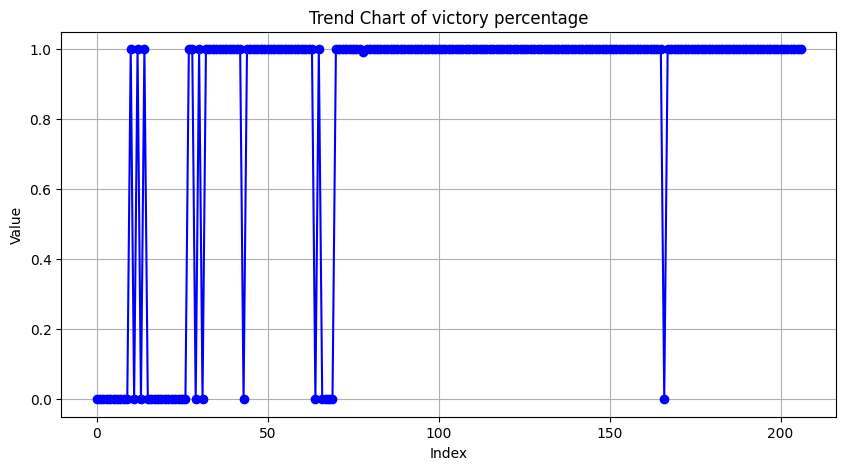

: 

In [ ]:
import matplotlib.pyplot as plt

# Creating a trend chart
plt.figure(figsize=(10, 5))
plt.plot(wins_and_draws, marker='o', linestyle='-', color='b')
plt.title('Trend Chart of victory percentage of the trained agent (DDQN)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()